# BTHSA PM2.5 Deweathering and SHAP

This notebook reproduces the Dai/Hou-style annual deweathering and SHAP analysis on the repository-local BTHSA panel. The first-pass target is historical alignment, not the 2025 Spring Festival counterfactual case.

## Experiment Contract

- Data: `data/dataset_bthsa_yrd_aqi_mete_emis.nc` plus `data/stations_bthsa.csv`.
- Scope: 228 BTHSA stations aggregated to 28 city-level hourly series by city mean.
- Target: city-level hourly `PM2.5`.
- Model: `sklearn.ensemble.RandomForestRegressor`.
- SHAP: `shap.TreeExplainer` on the final all-year city models.
- Split for diagnostic performance: train `2016-2021`, validation `2022`, test `2023`.
- Outputs: reusable CSV/NPZ caches under `exp/cache/bthsa_pm25_deweather_shap/` and figures under `fig/bthsa_pm25_deweather_shap/`.

In [12]:
from pathlib import Path
import importlib
import subprocess
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "dataset_bthsa_yrd_aqi_mete_emis.nc").exists():
    ROOT = ROOT.parent

print(f"Kernel Python: {sys.executable}")
print(sys.version)

try:
    shap = importlib.import_module("shap")
except ImportError:
    print("SHAP is missing in this kernel. Installing into the active kernel environment...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "shap==0.44.1",
        "numpy<2",
        "pandas<3",
        "scikit-learn<1.4",
        "scipy<1.12",
        "numba<0.60",
    ])
    importlib.invalidate_caches()
    shap = importlib.import_module("shap")

print(f"SHAP: {shap.__version__}")
ROOT


Kernel Python: /opt/anaconda3/bin/python
3.11.8 | packaged by conda-forge | (main, Feb 16 2024, 20:49:36) [Clang 16.0.6 ]
SHAP: 0.44.1


PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn')

In [13]:
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from scripts import bthsa_pm25_deweather_shap as exp

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## Run Settings

Keep `RUN_SMOKE = True` for quick validation. Set it to `False` for the full 28-city, 2016-2023 run. The full run trains one Random Forest per city and computes sampled SHAP values, so it can take a while.

In [14]:
RUN_SMOKE = False

config = exp.build_config(root_dir=ROOT, smoke=RUN_SMOKE)
config

ExperimentConfig(root_dir=PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn'), dataset_path=PosixPath('data/dataset_bthsa_yrd_aqi_mete_emis.nc'), station_path=PosixPath('data/stations_bthsa.csv'), cache_dir=PosixPath('exp/cache/bthsa_pm25_deweather_shap'), fig_dir=PosixPath('fig/bthsa_pm25_deweather_shap'), random_state=0, n_estimators=200, min_samples_leaf=5, n_jobs=-1, shap_sample_per_city=5000, deweather_samples=1000, smoke=False, smoke_cities=('beijing', 'tianjin'), smoke_hours_per_city=2000)

## Execute Pipeline

The helper writes all reusable artifacts as it runs: city feature table, model metrics, deweathered PM2.5, SHAP samples, SHAP global importance, and figures.

In [ ]:
result = exp.run_experiment(config)

features = result["features"]
metrics = result["metrics"]
deweathered = result["deweathered"]
importance = result["importance"]
plot_paths = result["plot_paths"]

features.shape, metrics.shape, deweathered.shape, importance.shape, len(plot_paths)

## Data Sanity Checks

In [ ]:
display(features.head())
print("cities", features["city_en"].nunique())
print("rows", len(features))
print("unique city-time rows", not features.duplicated(["time", "city_en"]).any())
print("splits")
display(features.groupby("split").size())

,time,city_en,city,station_count,PM2.5,O3,temp_c,dewpoint_c,RH,WS,WD_sin,WD_cos,sp,tp,blh,msdwswrf,delta_temp_24h,meic_PM25,meic_PM10,meic_NOx,meic_SO2,meic_VOC,meic_NH3,year,dayofyear_sin,dayofyear_cos,hour_sin,hour_cos,weekday_sin,weekday_cos,month_sin,month_cos,split
0,2016-01-02 11:00:00,beijing,北京市,24,275.750000,7.875000,1.566522,-5.882697,57.691300,0.679212,-0.663277,0.748374,99367.812500,-1.734723e-18,15.720666,0.000000e+00,2.455170,1.126322,1.616527,4.103111,0.705085,5.473381,0.191504,2016.0,0.034328,0.999411,0.258819,-0.965926,-0.974928,-0.222521,0.5,0.866025,train
1,2016-01-03 22:00:00,beijing,北京市,24,12.833333,52.083332,-3.404852,-13.608923,45.157258,4.967294,-0.056520,-0.998401,100233.023438,0.000000e+00,350.558807,5.684342e-14,-0.105713,1.095538,1.578398,3.644150,0.693071,5.039859,0.186926,2016.0,0.051479,0.998674,-0.500000,0.866025,-0.781831,0.623490,0.5,0.866025,train
2,2016-01-05 09:00:00,beijing,北京市,24,40.833332,29.166666,-1.518835,-15.950568,32.396235,2.477983,0.581881,0.813274,100063.343750,0.000000e+00,115.762321,4.972104e+01,-0.622375,1.191672,1.701227,4.455016,0.740422,5.874247,0.198683,2016.0,0.085731,0.996318,0.707107,-0.707107,0.781831,0.623490,0.5,0.866025,train
3,2016-01-06 20:00:00,beijing,北京市,24,9.791667,43.125000,-7.278387,-18.099234,41.726614,4.480802,0.297894,-0.954599,100653.757812,0.000000e+00,395.991852,0.000000e+00,0.817505,1.164208,1.652734,3.271301,0.738357,4.690737,0.196589,2016.0,0.102821,0.994700,-0.866025,0.500000,0.974928,-0.222521,0.5,0.866025,train
4,2016-01-08 07:00:00,beijing,北京市,24,9.083333,59.833332,0.852991,-18.473242,22.057798,1.990192,0.576057,-0.817410,99927.226562,0.000000e+00,1107.601074,3.412632e+02,0.942719,1.264621,1.756629,4.313875,0.776291,5.644014,0.216240,2016.0,0.136906,0.990584,0.965926,-0.258819,-0.433884,-0.900969,0.5,0.866025,train


cities 2
rows 3998
unique city-time rows True
splits


split
test      500
train    2998
val       500
dtype: int64

## Model Diagnostics

In [ ]:
metrics.sort_values(["split", "rmse"]).head(20)

,rmse,mae,corr,city_en,split,n_samples
5,34.413820,24.148723,0.566123,tianjin,test,250
2,35.206264,19.050370,0.486029,beijing,test,250
3,20.981261,12.263754,0.922455,tianjin,train,1499
0,22.889550,13.069753,0.917467,beijing,train,1499
1,25.036747,17.991690,0.605937,beijing,val,250
4,31.311835,21.555998,0.562591,tianjin,val,250


In [ ]:
test_metrics = metrics[metrics["split"] == "test"].sort_values("rmse")
display(test_metrics)
print("mean test RMSE", test_metrics["rmse"].mean())
print("mean test corr", test_metrics["corr"].mean())

,rmse,mae,corr,city_en,split,n_samples
5,34.413820,24.148723,0.566123,tianjin,test,250
2,35.206264,19.050370,0.486029,beijing,test,250


mean test RMSE 34.8100419410045
mean test corr 0.5260761142155344


## Deweathered PM2.5 Output

In [ ]:
display(deweathered.head())
regional = deweathered.groupby("time", as_index=False)[["PM2.5_obs", "PM2.5_deweathered", "meteo_component"]].mean()
display(regional.head())

,time,city_en,city,split,PM2.5_obs,PM2.5_deweathered,meteo_component
0,2016-01-02 11:00:00,beijing,北京市,train,275.750000,205.634176,70.115824
1,2016-01-03 22:00:00,beijing,北京市,train,12.833333,88.386091,-75.552758
2,2016-01-05 09:00:00,beijing,北京市,train,40.833332,95.533081,-54.699749
3,2016-01-06 20:00:00,beijing,北京市,train,9.791667,95.906723,-86.115056
4,2016-01-08 07:00:00,beijing,北京市,train,9.083333,95.431417,-86.348084


,time,PM2.5_obs,PM2.5_deweathered,meteo_component
0,2016-01-02 11:00:00,322.803589,211.477028,111.326545
1,2016-01-03 22:00:00,89.321426,133.610079,-44.288650
2,2016-01-05 09:00:00,40.464287,110.703526,-70.239241
3,2016-01-06 20:00:00,9.419643,100.951795,-91.532152
4,2016-01-08 07:00:00,13.041666,105.224710,-92.183043


## SHAP Summary

In [ ]:
global_importance = (
    importance.groupby("feature", as_index=False)["mean_abs_shap"]
    .mean()
    .sort_values("mean_abs_shap", ascending=False)
)
display(global_importance.head(25))

,feature,mean_abs_shap
0,O3,9.533364
2,WD_cos,7.407090
6,dayofyear_cos,6.101529
1,RH,4.674261
9,dewpoint_c,3.877342
26,year,3.806325
8,delta_temp_24h,3.082614
16,meic_SO2,2.925880
7,dayofyear_sin,2.706242
21,sp,2.686242


## Figure Preview

fig/bthsa_pm25_deweather_shap/model_performance_rmse.png


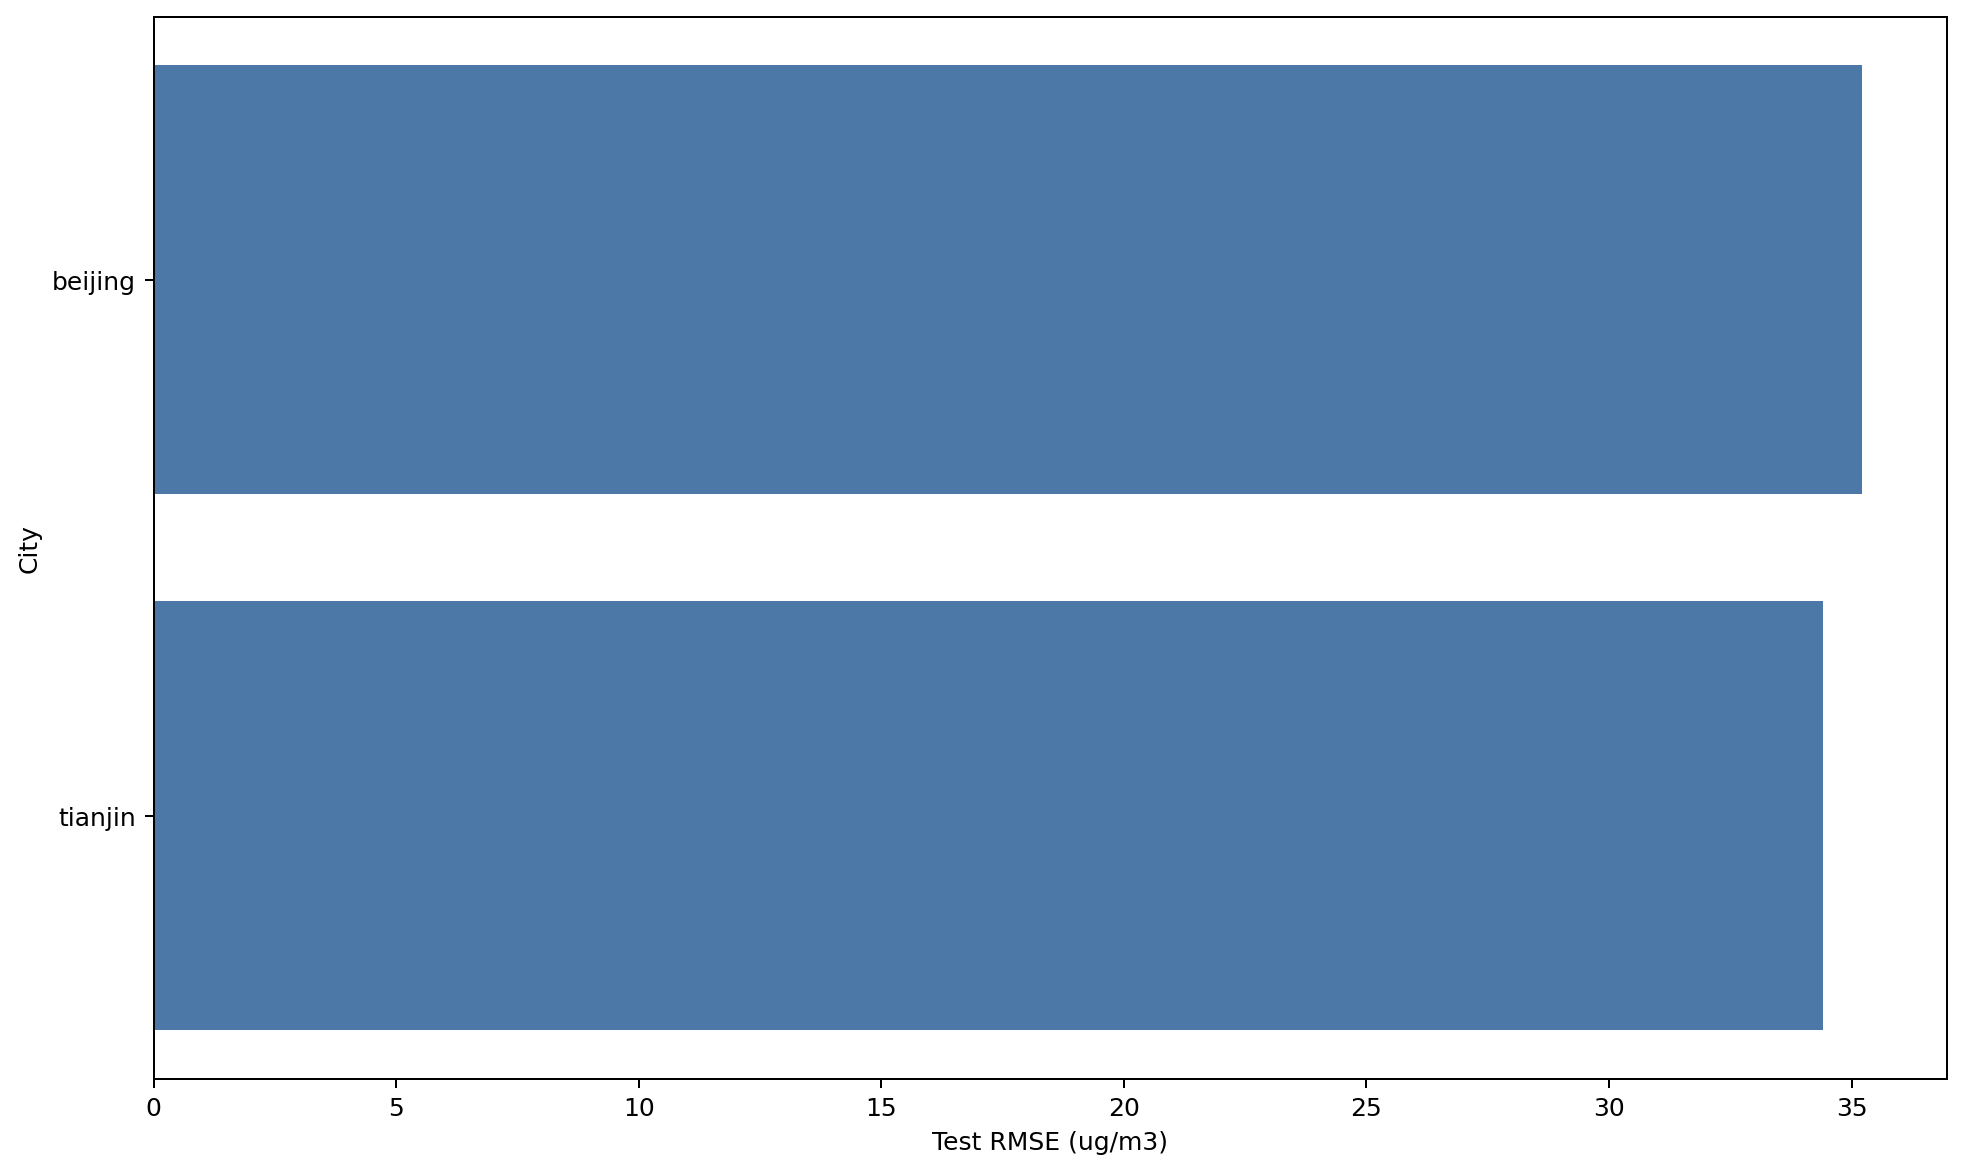

fig/bthsa_pm25_deweather_shap/regional_pm25_deweathered_timeseries.png


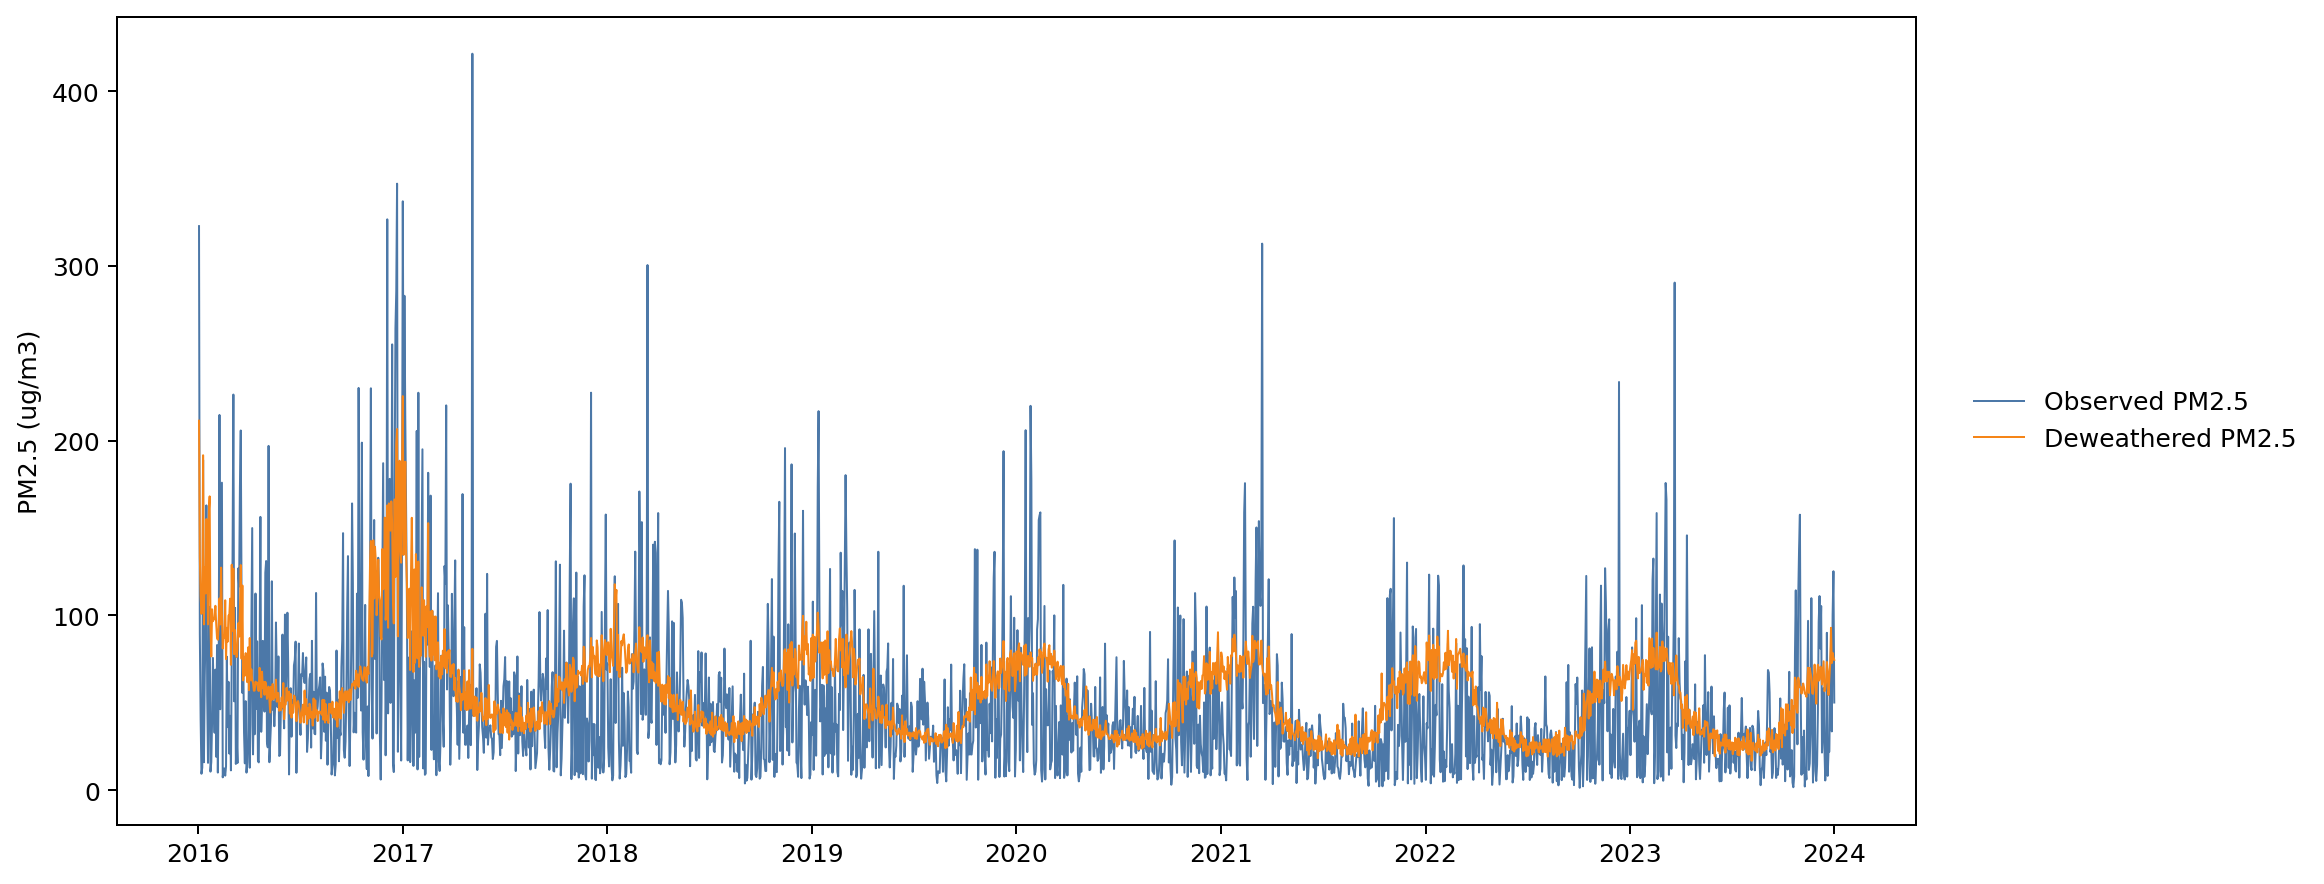

fig/bthsa_pm25_deweather_shap/shap_global_top_features.png


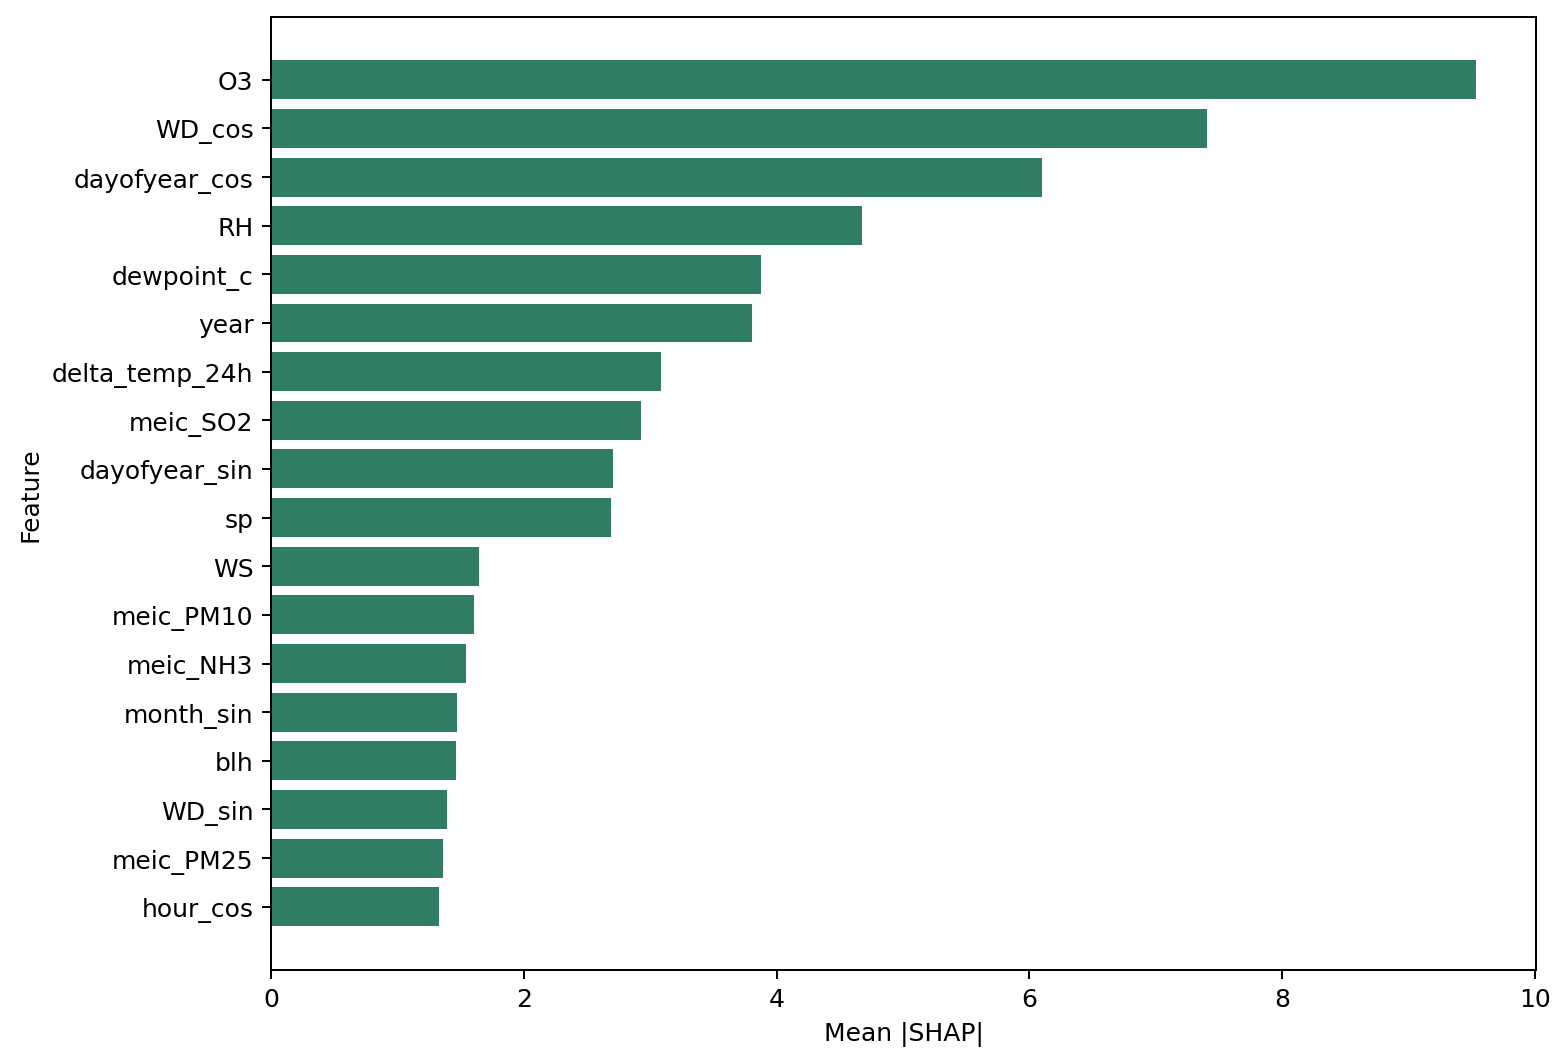

fig/bthsa_pm25_deweather_shap/city_feature_shap_heatmap.png


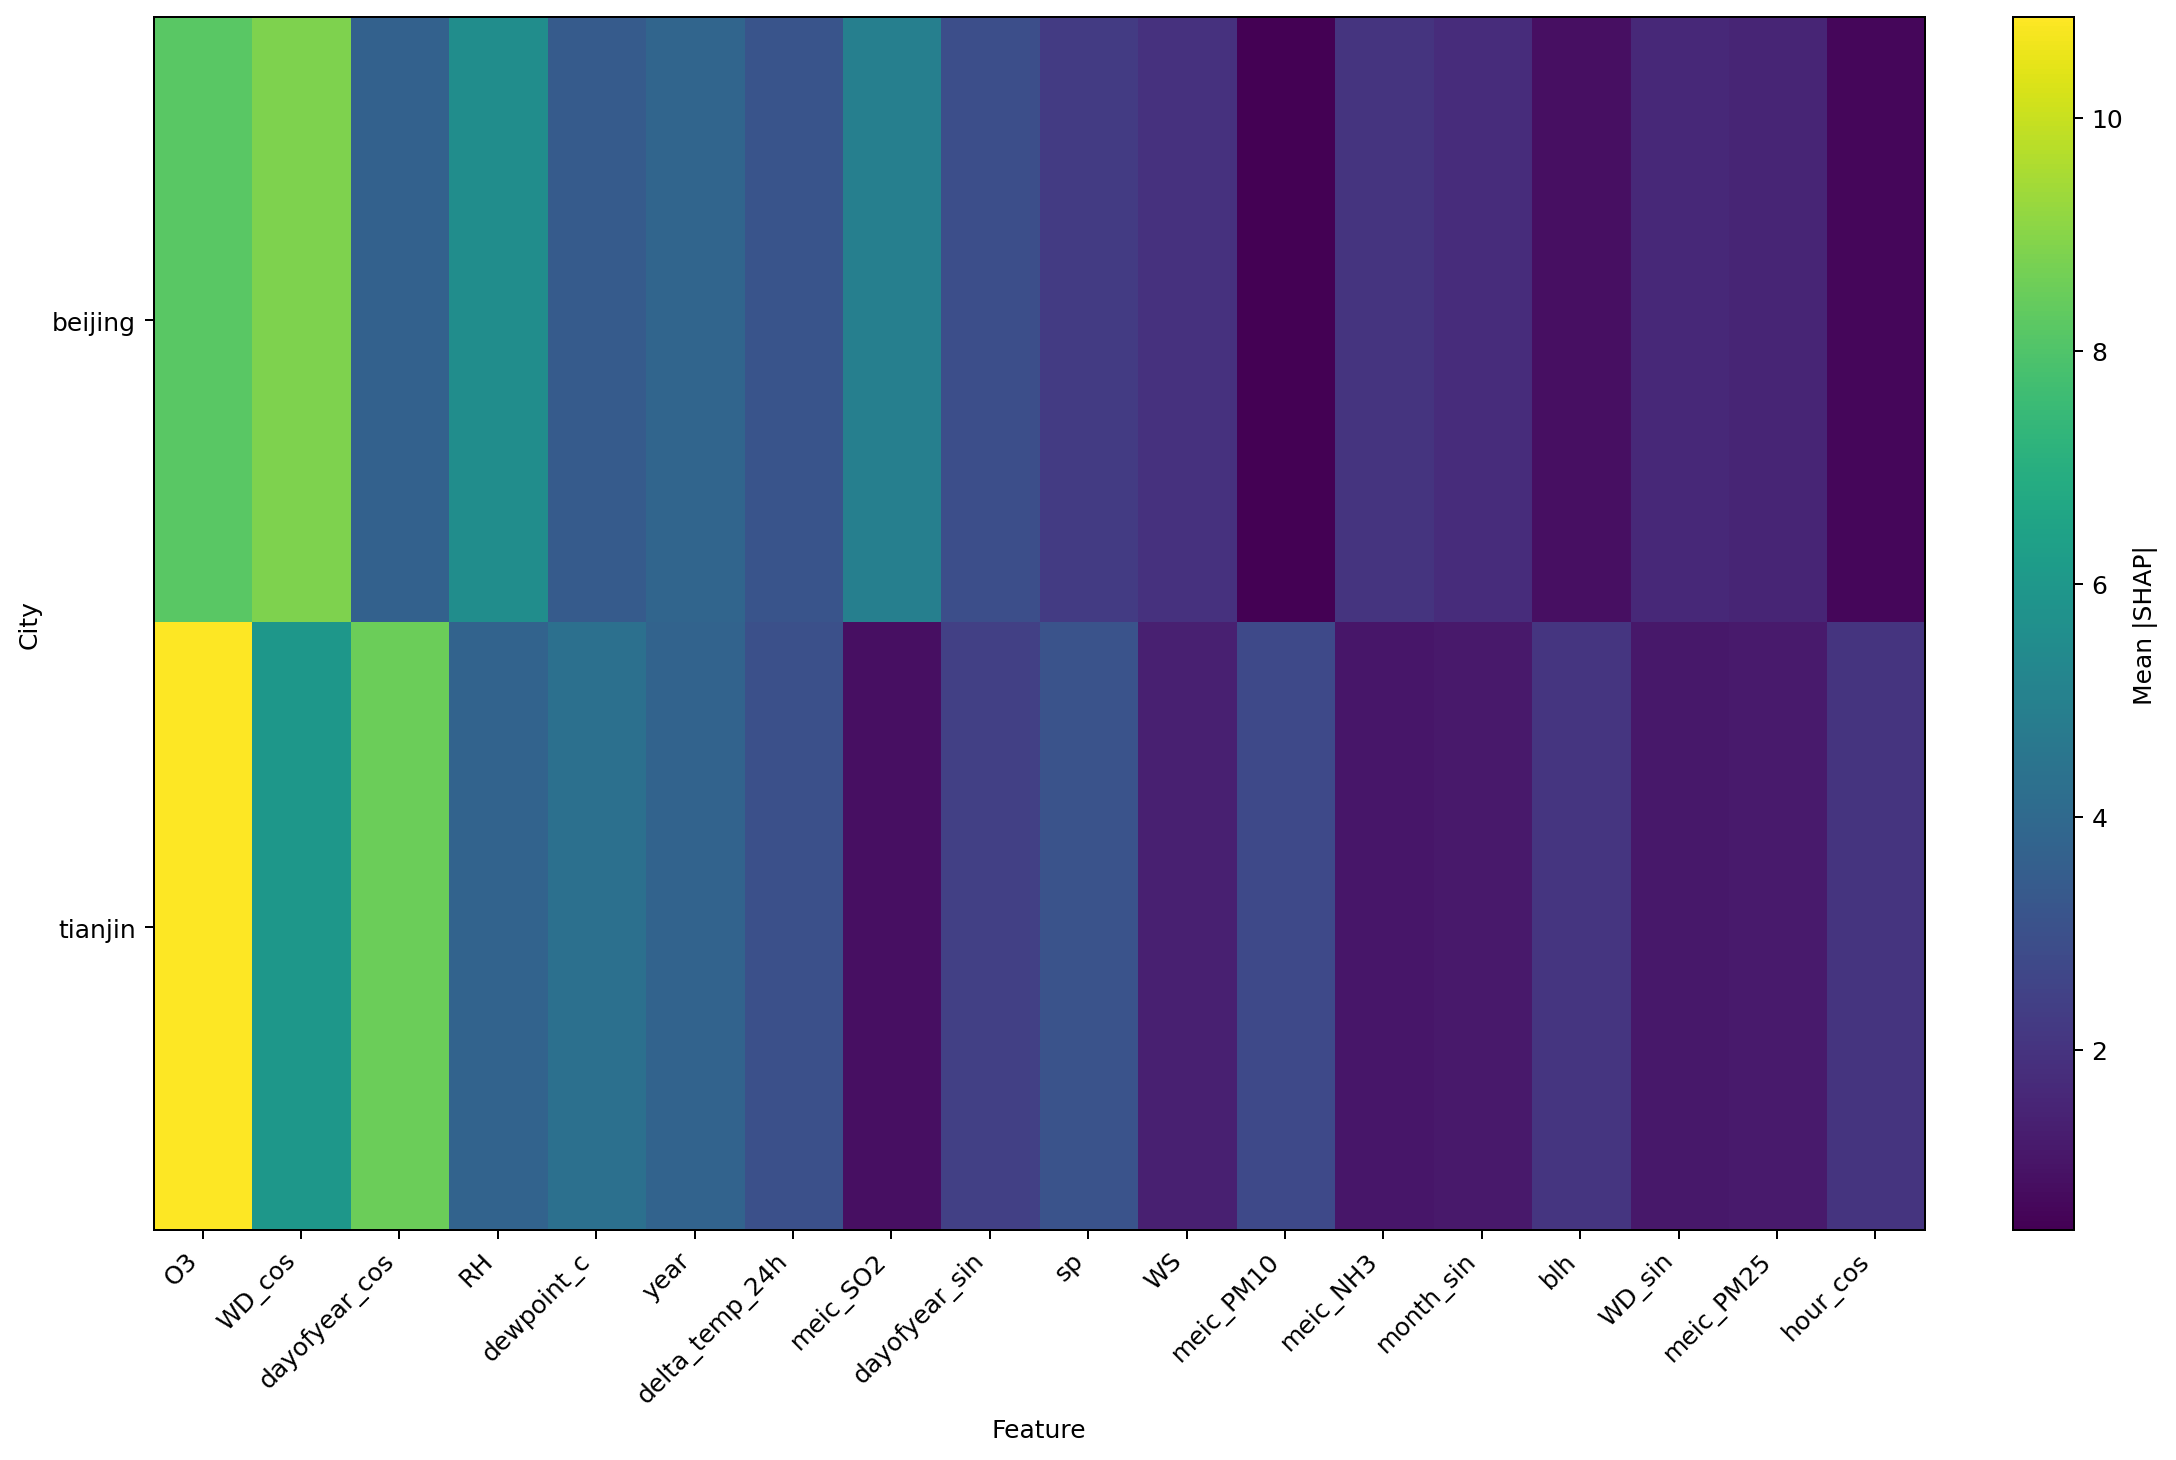

fig/bthsa_pm25_deweather_shap/shap_dependence_RH.png


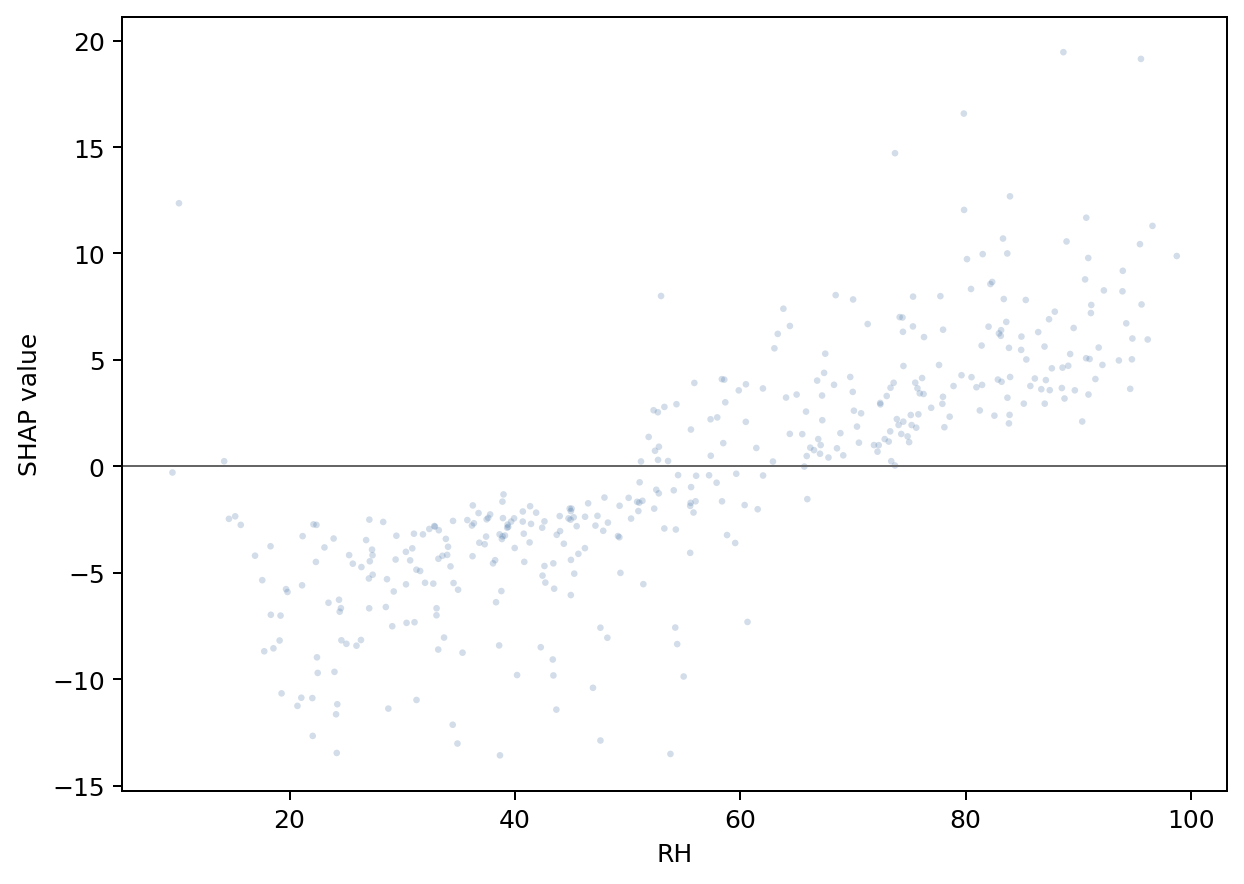

fig/bthsa_pm25_deweather_shap/shap_dependence_temp_c.png


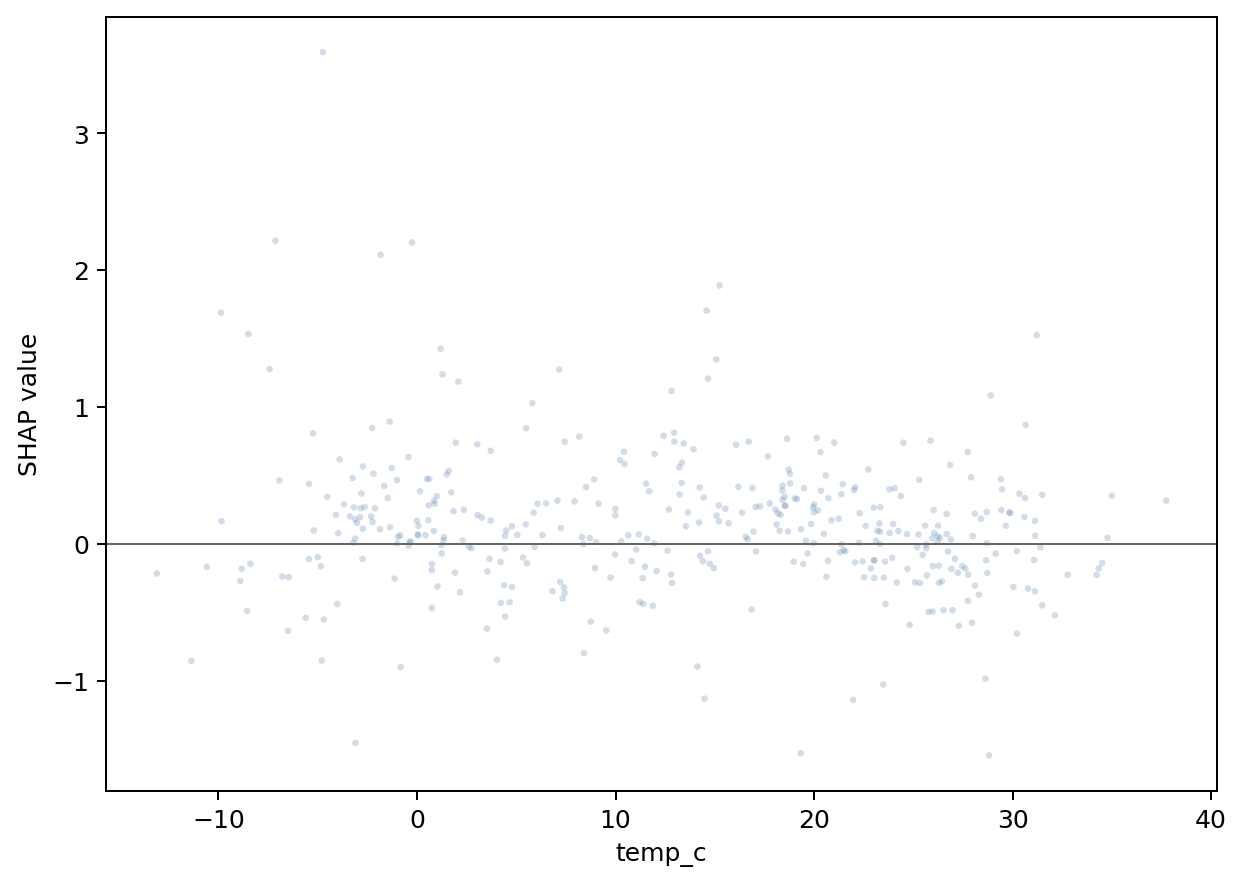

In [ ]:
from IPython.display import Image, display

for path in plot_paths[:6]:
    print(path.relative_to(ROOT))
    display(Image(filename=str(path)))

## Artifact Manifest

In [ ]:
for artifact in [
    config.resolved_cache_dir / "city_hourly_features.csv",
    config.resolved_cache_dir / "model_metrics.csv",
    config.resolved_cache_dir / "deweathered_pm25.csv",
    config.resolved_cache_dir / "shap_values_sampled.npz",
    config.resolved_cache_dir / "shap_global_importance.csv",
]:
    print(artifact.relative_to(ROOT), artifact.exists(), artifact.stat().st_size if artifact.exists() else None)

for path in plot_paths:
    print(path.relative_to(ROOT), path.exists())

exp/cache/bthsa_pm25_deweather_shap/city_hourly_features.csv True 1791862
exp/cache/bthsa_pm25_deweather_shap/model_metrics.csv True 480
exp/cache/bthsa_pm25_deweather_shap/deweathered_pm25.csv True 359763
exp/cache/bthsa_pm25_deweather_shap/shap_values_sampled.npz True 99506
exp/cache/bthsa_pm25_deweather_shap/shap_global_importance.csv True 3241
fig/bthsa_pm25_deweather_shap/model_performance_rmse.png True
fig/bthsa_pm25_deweather_shap/regional_pm25_deweathered_timeseries.png True
fig/bthsa_pm25_deweather_shap/shap_global_top_features.png True
fig/bthsa_pm25_deweather_shap/city_feature_shap_heatmap.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_RH.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_temp_c.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_blh.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_WS.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_msdwswrf.png True
fig/bthsa_pm25_deweather_shap/shap_dependence_O3.png True
fig/bthsa_pm25_deweather